# CS 383 - Machine Learning
## Lab 5 - Logistic Regression

### Introduction
In this lab you will implement Logistic Regression classifiers for the purpose of binary classification.  For exploritory purposes, we'll do this on a simple dummy dataset.

As with all labs, you cannot use any functions that are against the "spirit" of the lab.  No ML framework or usage of functions related to logistic regression.

### Grading
| Points | Description |
| ------- | --------|
|  +1pt|   Create dataset correctly | 
| +1pt | Zscores correctly
|  +1pt|  Does some gradient based computations. | 
|  +1pt|  Does some learning.| 
|  +1pt|  Correct termination criteria set up.| 
|  +1pt|  Creates some plot.| 
|  +1pts|  Creates correct plot.| 
|  +1pt|  Runs to convergence.| 
|  +2pts | Provides requested statistics and weights.| 
| ------ | ------ |
| 10pts | Total |

### Our Data
To ensure that our logistic regression model is learning we'll use a very simple toy dataset consisting of just two observations (one for each class).  The dataset is as follows:

$$X=\begin{bmatrix}1 & 2 & -3\\-1 & 0 & 10\end{bmatrix}, Y=\begin{bmatrix}0\\1\end{bmatrix}$$

In [66]:
#TODO
#Create your observable data matrix as X and Target matrix as Y
import numpy as np
X = np.array([[1,2,-3],[-1,0,10]])
Y = np.array([[0],[1]])
print(X)
print(Y)

[[ 1  2 -3]
 [-1  0 10]]
[[0]
 [1]]


### Logistic Regression
Lets design, implement and train  a *Logistic Regression Classifier*.  For training we'll use the dataset mentioned earlier.

Your code should:
1. Standardize the features
2. Add a bias feature
3. Train a logistic classifier, keeping track of the mean log loss each iteration.
  
#### Implementation Details
-  Seed the random number generator prior to initializing the weights randomly.
-  We will let you determine appropriate values for the learning rate, $\eta$, the initial parameter values, as well as an appropriate termination criteria.-
-  Make sure to add a numeric stability constant, as needed.
-  For full credit, you must run your algorithm to *convergence* (or at least until visually it pretty much flattens out).

In [94]:
#TODO Create linear regression model as described above
mean = np.mean(X, axis=0)
stddev = np.std(X, axis=0, ddof=1)

Xz = X - mean
Xz = Xz / stddev
print(Xz)
X2 = np.concatenate((Xz, np.ones((Xz.shape[0],1))),axis=1)
print(X2)

rng = np.random.default_rng(0)

W = np.array([[1],[1],[1],[1]])
#W = rng.uniform(0, 1, 4)
print(W)

N = X2.shape[0]
print(N)

MAX_EPOCHS = 1000
learningRate = 0.25

losses = []
epochs = []

epsilon = 10**-7
for i in range(MAX_EPOCHS):
    XW = X2@W
    yhati= 1 / (1 + np.exp(-(XW)))
    
    dJdw = (1/N) * (X2.T @ (yhati - Y))
    
    W = W - learningRate*dJdw
    
    log_loss = -(Y*np.log(yhati+epsilon) + (1-Y)*np.log(1-yhati+epsilon))
    losses.append(np.mean(log_loss))
    epochs.append(i+1)

print("W after", MAX_EPOCHS, "epochs")
print(W)

[[ 0.70710678  0.70710678 -0.70710678]
 [-0.70710678 -0.70710678  0.70710678]]
[[ 0.70710678  0.70710678 -0.70710678  1.        ]
 [-0.70710678 -0.70710678  0.70710678  1.        ]]
[[1]
 [1]
 [1]
 [1]]
2
W after 1000 epochs
[[-2.12244147]
 [-2.12244147]
 [ 4.12244147]
 [ 0.02692505]]


### Evaluation
Finally, provide the following information:
- Plot of epoch vs mean negative log loss.
- Accuracy, assigning any observation with a predicted probability $\ge 50\%$ to be class one (1) and class zero (0) otherwise.
- Displays the learned weights.

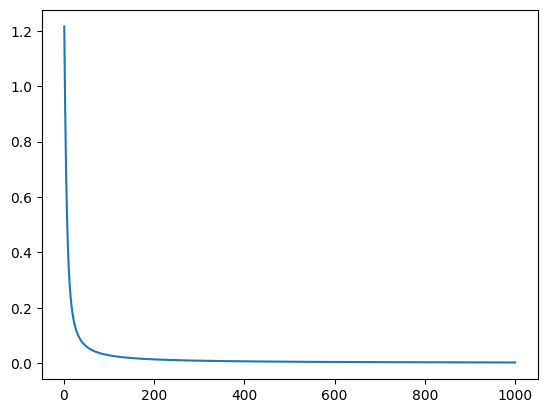

[[0.00276026]
 [0.99738407]]
[[0.00276026]
 [0.99738407]]
Predictions:
[[0]
 [1]]
Accuracy: 
1.0
W after 1000 epochs
[[-2.12244147]
 [-2.12244147]
 [ 4.12244147]
 [ 0.02692505]]


In [101]:
#TODO:  Displays information requested above.
import matplotlib.pyplot as plt
# print(losses)
# print(epochs)
x = np.array(epochs)
y = np.array(losses)
plt.plot(x,y)
plt.show()

XW = X2@W
yhat= 1 / (1+np.exp(-(XW)))
print(yhat)
prob_y1 = yhat
print(prob_y1)
predictions = np.where(prob_y1 >= 0.5, 1, 0)
print("Predictions:")
print(predictions)
print("Accuracy: ")
accuracy = np.mean(Y == predictions)
print(accuracy)
print("W after", MAX_EPOCHS, "epochs")
print(W)